<a href="https://colab.research.google.com/github/6hamuge/Beyond-ETRI/blob/main/PTDT_v5_Improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dual-Tower PTDT v5 (성능 개선 4종 적용)

## v4 -> v5 변경 내역

| 우선순위 | 셀 위치 | 변경 내용 |
|----------|---------|-----------|
| 1순위 | Cell 21 (loss 함수) | pos_weight: 양성 레이블 가중치 부여 |
| 2순위 | Cell 23 (CONFIG) | 모델 축소: d_model 64→32, n_layers 2→1, dropout 0.25→0.35 |
| 3순위 | Cell 17 (Dataset) | 데이터 증강: Gaussian noise (학습용만 augment=True) |
| 3순위 | Cell 24 (LOSO loop) | train_ds에 augment=True 전달 |
| 4순위 | Cell 21 (loss 함수) | Label smoothing: 레이블 0/1을 0.05/0.95로 완화 |

v4의 도메인 피처, v3의 threshold 탐색·누적피처·Q/S SEQ 분리는 모두 유지됩니다.

---

### 변경 이유 요약

| 문제 | 원인 | v5 해결책 |
|------|------|-----------|
| threshold 0.32~0.37 (너무 낮음) | 음성 예측이 loss에 유리 | pos_weight로 양성 loss 가중치 증가 |
| AUC 표준편차 0.1 이상 | 450샘플에 모델이 너무 큼 | d_model/n_layers 축소 + dropout 강화 |
| 학습 데이터 부족 | LOSO 기준 ~400샘플 | Gaussian noise augmentation |
| 확률 극단값 쏠림 | hard target 0/1 | label smoothing 0.05 |


## 0. 환경 설정

In [ ]:
import sys
IN_COLAB = 'google.colab' in sys.modules
print(f'Colab: {IN_COLAB}')
!pip install pyarrow pandas numpy scikit-learn torch matplotlib seaborn tqdm -q
print('✅ 설치 완료')

Colab: True
✅ 설치 완료


## 1. 데이터 업로드

parquet 12개 + `ch2026_metrics_train.csv` 총 13개 업로드
> `lifelog_date` = 센서 수집일 (merge key)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/ch2025/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 직접 업로드 방식
# from google.colab import files
# uploaded = files.upload()
# DATA_DIR = '/content/'

## 2. 데이터 로딩

In [ ]:
import pandas as pd
import numpy as np
import os, warnings, math, copy
warnings.filterwarnings('ignore')

FILE_MAP = {
    'ac_status'  : 'ch2025_mACStatus.parquet',
    'activity'   : 'ch2025_mActivity.parquet',
    'ambience'   : 'ch2025_mAmbience.parquet',
    'ble'        : 'ch2025_mBle.parquet',
    'gps'        : 'ch2025_mGps.parquet',
    'light'      : 'ch2025_mLight.parquet',
    'screen'     : 'ch2025_mScreenStatus.parquet',
    'usage_stats': 'ch2025_mUsageStats.parquet',
    'wifi'       : 'ch2025_mWifi.parquet',
    'hr'         : 'ch2025_wHr.parquet',
    'w_light'    : 'ch2025_wLight.parquet',
    'pedo'       : 'ch2025_wPedo.parquet',
}

raw = {}
for key, fname in FILE_MAP.items():
    path = os.path.join(DATA_DIR, 'ch2025_data_items/', fname)
    if os.path.exists(path):
        raw[key] = pd.read_parquet(path)
        print(f'✅ {key:12s}: {raw[key].shape}  cols: {list(raw[key].columns)}')
    else:
        print(f'❌ {key}: 없음 ({path})')
print(f'\n로드 완료: {len(raw)}개')

✅ ac_status   : (939896, 3)  cols: ['subject_id', 'timestamp', 'm_charging']
✅ activity    : (961062, 3)  cols: ['subject_id', 'timestamp', 'm_activity']
✅ ambience    : (476577, 3)  cols: ['subject_id', 'timestamp', 'm_ambience']
✅ ble         : (21830, 3)  cols: ['subject_id', 'timestamp', 'm_ble']
✅ gps         : (800611, 3)  cols: ['subject_id', 'timestamp', 'm_gps']
✅ light       : (96258, 3)  cols: ['subject_id', 'timestamp', 'm_light']
✅ screen      : (939653, 3)  cols: ['subject_id', 'timestamp', 'm_screen_use']
✅ usage_stats : (45197, 3)  cols: ['subject_id', 'timestamp', 'm_usage_stats']
✅ wifi        : (76336, 3)  cols: ['subject_id', 'timestamp', 'm_wifi']
✅ hr          : (382918, 3)  cols: ['subject_id', 'timestamp', 'heart_rate']
✅ w_light     : (633741, 3)  cols: ['subject_id', 'timestamp', 'w_light']
✅ pedo        : (748100, 9)  cols: ['subject_id', 'timestamp', 'step', 'step_frequency', 'running_step', 'walking_step', 'distance', 'speed', 'burned_calories']

로드 완료: 12개

## 3. 레이블 로딩

In [ ]:
LABEL_COLS = ['Q1','Q2','Q3','S1','S2','S3','S4']
Q_COLS     = ['Q1','Q2','Q3']
S_COLS     = ['S1','S2','S3','S4']

labels_df = pd.read_csv(os.path.join(DATA_DIR, 'ch2026_metrics_train.csv'))
labels_df['sleep_date']   = pd.to_datetime(labels_df['sleep_date'])
labels_df['lifelog_date'] = pd.to_datetime(labels_df['lifelog_date'])
labels_df[LABEL_COLS]     = labels_df[LABEL_COLS].astype(int)

print(f'✅ 레이블: {labels_df.shape}')
print(f'   피험자: {sorted(labels_df["subject_id"].unique())}')
print()
for lc in LABEL_COLS:
    vc  = labels_df[lc].value_counts().sort_index()
    pct = vc.get(1,0)/len(labels_df)*100
    bar = '█'*int(pct/5)+'░'*(20-int(pct/5))
    print(f'  {lc}: [{bar}] {pct:.1f}% 양성')
display(labels_df.head(3))

✅ 레이블: (450, 10)
   피험자: ['id01', 'id02', 'id03', 'id04', 'id05', 'id06', 'id07', 'id08', 'id09', 'id10']

  Q1: [█████████░░░░░░░░░░░] 49.6% 양성
  Q2: [███████████░░░░░░░░░] 56.2% 양성
  Q3: [████████████░░░░░░░░] 60.0% 양성
  S1: [█████████████░░░░░░░] 68.2% 양성
  S2: [█████████████░░░░░░░] 65.1% 양성
  S3: [█████████████░░░░░░░] 66.2% 양성
  S4: [███████████░░░░░░░░░] 56.0% 양성


,subject_id,sleep_date,lifelog_date,Q1,Q2,Q3,S1,S2,S3,S4
0,id01,2024-06-27,2024-06-26,0,0,0,0,0,1,0
1,id01,2024-06-28,2024-06-27,0,0,0,0,1,1,1
2,id01,2024-06-29,2024-06-28,1,0,0,1,1,1,1


## 4. 피처 엔지니어링

> **[수정 B] 누적 피처 추가** — 취침 전 피로(Q2)는 당일 값보다 며칠 누적 활동량이 핵심 신호.
> `pedo(걸음수)`, `hr(심박)`, `screen(화면사용)` 의 3일·5일 rolling sum을 별도 피처로 추가.


In [ ]:
def get_timestamp_col(df):
    for c in df.columns:
        if any(k in c.lower() for k in ['timestamp','time','datetime','ts','date']):
            return c
    for c in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[c]):
            return c
    return None

def extract_daily_features(df, sensor_name, subject_col='subject_id'):
    df = df.copy()
    ts_col = get_timestamp_col(df)
    if ts_col and ts_col in df.columns:
        df[ts_col] = (pd.to_datetime(df[ts_col], unit='ms', errors='coerce')
                      if df[ts_col].dtype in ['int64','float64']
                      else pd.to_datetime(df[ts_col], errors='coerce'))
        df['date'] = df[ts_col].dt.date
    elif 'date' not in df.columns:
        print(f'  ⚠️  [{sensor_name}] 타임스탬프 없음'); return None
    df['date'] = pd.to_datetime(df['date'])
    exclude  = {subject_col, 'date', ts_col}
    num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]
    if not num_cols: return None
    grp   = df.groupby([subject_col,'date'])[num_cols]
    parts = []
    for agg_name, agg_df in {
        'mean':grp.mean(), 'std':grp.std().fillna(0),
        'min':grp.min(),   'max':grp.max(), 'count':grp.count()
    }.items():
        agg_df.columns = [f'{sensor_name}__{c}__{agg_name}' for c in agg_df.columns]
        parts.append(agg_df)
    result = pd.concat(parts, axis=1).reset_index()
    print(f'  ✅ [{sensor_name}]: {result.shape[1]-2}개 피처')
    return result

print('📊 일별 피처 추출...')
daily_features = {k: extract_daily_features(df, k) for k,df in raw.items()}
daily_features = {k:v for k,v in daily_features.items() if v is not None}

from functools import reduce
feature_df = reduce(
    lambda l,r: pd.merge(l,r,on=['subject_id','date'],how='outer'),
    daily_features.values()
)
print(f'\n✅ 통합 피처: {feature_df.shape}')

📊 일별 피처 추출...
  ✅ [ac_status]: 5개 피처
  ✅ [activity]: 5개 피처
  ✅ [light]: 5개 피처
  ✅ [screen]: 5개 피처
  ✅ [w_light]: 5개 피처
  ✅ [pedo]: 35개 피처

✅ 통합 피처: (700, 62)


## 4-B. 도메인 특화 피처 엔지니어링

[v4 신규] 시간대별 도메인 피처

수면, 피로, 스트레스는 하루 평균이 아닌 시간대가 중요합니다.

| 구간 | 시각 | 관련 지표 |
|------|------|-----------|
| 주간 | 08-21시 | Q2(신체 피로), Q3(스트레스 원인) |
| 취침 전 | 21-24시 | Q3, S3(SOL), 수면 준비도 |
| 야간 | 00-07시 | Q1, S1(TST), S2(수면효율), S4(WASO) |


In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Time window definitions
DAYTIME     = (8,  21)   # Daytime
PRESLEEP    = (21, 24)   # Pre-sleep (21h-midnight)
SLEEP_NIGHT = (0,  7)    # Sleep period (midnight-7h)

def _parse_ts(df):
    '''Parse timestamp column, add date and hour columns'''
    df = df.copy()
    ts_col = None
    for c in df.columns:
        if any(k in c.lower() for k in ['timestamp','time','ts','datetime']):
            ts_col = c; break
    if ts_col is None:
        return None
    if df[ts_col].dtype in ['int64','float64']:
        df['_dt'] = pd.to_datetime(df[ts_col], unit='ms', errors='coerce')
    else:
        df['_dt'] = pd.to_datetime(df[ts_col], errors='coerce')
    df['date'] = df['_dt'].dt.normalize()
    df['hour'] = df['_dt'].dt.hour
    return df

def _wmask(df, h_start, h_end):
    '''Time window boolean mask. Handles cross-midnight ranges.'''
    if h_end >= h_start:
        return (df['hour'] >= h_start) & (df['hour'] < h_end)
    return (df['hour'] >= h_start) | (df['hour'] < h_end)


# ------------------------------------------------------------------
# 1. wHr -- heart rate
#   Q1: night HR mean/std/min (sleep depth)
#   Q2: day max HR, high-intensity fraction (exercise intensity)
#   Q3: pre-sleep HR mean and trend (stress)
#   S1: HR<60 fraction (total sleep time proxy)
#   S2: night HR std (arousal frequency)
#   S4: night HR spike count (mid-sleep awakenings)
# ------------------------------------------------------------------
def _feat_hr(df):
    df = _parse_ts(df)
    if df is None: return pd.DataFrame()
    hr_col = next((c for c in df.columns
                   if 'heart' in c.lower() or c.lower() in ['hr','bpm']), None)
    if hr_col is None: return pd.DataFrame()
    rows = []
    for (subj, date), g in df.groupby(['subject_id','date']):
        r = {'subject_id': subj, 'date': date}
        day   = g[_wmask(g, *DAYTIME)][hr_col].dropna()
        pre   = g[_wmask(g, *PRESLEEP)][hr_col].dropna()
        night = g[_wmask(g, *SLEEP_NIGHT)][hr_col].dropna()
        # daytime
        r['hr_day_mean']       = day.mean()
        r['hr_day_max']        = day.max()           # Q2
        r['hr_day_above100']   = (day > 100).mean()  # Q2 high intensity
        r['hr_day_std']        = day.std()
        # pre-sleep
        r['hr_presleep_mean']  = pre.mean()          # Q3
        r['hr_presleep_trend'] = (
            pre.iloc[-len(pre)//3:].mean() - pre.iloc[:len(pre)//3].mean()
            if len(pre) >= 6 else np.nan
        )  # negative=relaxing, positive=aroused (Q3)
        # nighttime
        r['hr_night_mean']       = night.mean()      # Q1
        r['hr_night_std']        = night.std()       # S2
        r['hr_night_min']        = night.min()       # Q1
        r['hr_night_sleep_frac'] = (night < 60).mean() if len(night) > 0 else np.nan  # S1
        if len(night) > 10:
            above = (night > 75).astype(int)
            r['hr_night_spikes'] = (above.diff().fillna(0) == 1).sum()  # S4
        else:
            r['hr_night_spikes'] = np.nan
        rows.append(r)
    return pd.DataFrame(rows)


# ------------------------------------------------------------------
# 2. wPedo -- steps / distance / calories
#   Q2: total steps, calories, active minutes (physical load)
#   Q3: sedentary hours (cognitive stress without movement)
#   S1: night zero-step fraction (sleep time proxy)
# ------------------------------------------------------------------
def _feat_pedo(df):
    df = _parse_ts(df)
    if df is None: return pd.DataFrame()
    steps_col = next((c for c in df.columns if 'step' in c.lower()), None)
    dist_col  = next((c for c in df.columns if 'dist' in c.lower()), None)
    cal_col   = next((c for c in df.columns if 'cal'  in c.lower()), None)
    rows = []
    for (subj, date), g in df.groupby(['subject_id','date']):
        r = {'subject_id': subj, 'date': date}
        if steps_col:
            day_s = g[_wmask(g, *DAYTIME)][steps_col].dropna()
            r['pedo_total_steps']     = day_s.sum()           # Q2
            r['pedo_active_mins']     = (day_s > 0).sum()     # Q2
            r['pedo_peak_steps']      = day_s.max()           # Q2 intensity
            night_s = g[_wmask(g, *SLEEP_NIGHT)][steps_col].dropna()
            r['pedo_night_zero_frac'] = (night_s == 0).mean() # S1
            r['pedo_sedentary_hrs']   = (day_s < 5).sum() / 60  # Q3
        if cal_col:
            r['pedo_total_calories']  = g[cal_col].sum()      # Q2
        if dist_col:
            r['pedo_total_distance']  = g[dist_col].sum()     # Q2
        rows.append(r)
    return pd.DataFrame(rows)


# ------------------------------------------------------------------
# 3. mActivity -- activity type (0=still,2=walk,4=run,8=cycle)
#   Q2: vigorous fraction (exercise load)
#   Q3: daytime still fraction (sedentary)
#   S1: nighttime still fraction (sleep proxy)
#   S2/Q1: nighttime movement count (mid-sleep arousals)
#   S3: last active hour before sleep (sleep readiness)
# ------------------------------------------------------------------
def _feat_activity(df):
    df = _parse_ts(df)
    if df is None: return pd.DataFrame()
    act_col = next((c for c in df.columns
                    if 'activity' in c.lower() or 'type' in c.lower()), None)
    if act_col is None: return pd.DataFrame()
    STILL    = 0
    VIGOROUS = [4, 8]
    rows = []
    for (subj, date), g in df.groupby(['subject_id','date']):
        r = {'subject_id': subj, 'date': date}
        g = g.sort_values('_dt')
        day   = g[_wmask(g, *DAYTIME)][act_col].dropna()
        night = g[_wmask(g, *SLEEP_NIGHT)][act_col].dropna()
        pre   = g[_wmask(g, *PRESLEEP)].sort_values('_dt')
        r['act_vigorous_frac']        = day.isin(VIGOROUS).mean()  # Q2
        r['act_walking_frac']         = (day == 2).mean()           # Q2
        r['act_still_day_frac']       = (day == STILL).mean()       # Q3
        r['act_still_night_frac']     = (night == STILL).mean()     # S1
        r['act_night_movement_count'] = (night != STILL).sum()      # S2/Q1
        if len(pre) > 0:
            ns = pre[pre[act_col] != STILL]
            r['act_presleep_last_active_hour'] = ns['hour'].iloc[-1] if len(ns) > 0 else 21  # S3
        rows.append(r)
    return pd.DataFrame(rows)


# ------------------------------------------------------------------
# 4. mScreenStatus -- screen on(1)/off(0)
#   Q3: pre-sleep on count (arousal maintenance)
#   S1: night off fraction (sleep time proxy)
#   S3: last off hour (sleep onset estimate)
#   S4: night on count (phone checks during sleep)
# ------------------------------------------------------------------
def _feat_screen(df):
    df = _parse_ts(df)
    if df is None: return pd.DataFrame()
    st_col = next((c for c in df.columns
                   if 'status' in c.lower() or 'screen' in c.lower()
                   or 'state' in c.lower()), None)
    if st_col is None: return pd.DataFrame()
    rows = []
    for (subj, date), g in df.groupby(['subject_id','date']):
        r = {'subject_id': subj, 'date': date}
        g = g.sort_values('_dt')
        pre   = g[_wmask(g, *PRESLEEP)]
        night = g[_wmask(g, *SLEEP_NIGHT)]
        if len(pre) > 0:
            on = (pre[st_col] == 1)
            r['screen_presleep_on_count'] = on.sum()    # Q3
            r['screen_presleep_on_frac']  = on.mean()   # Q3
            off_t = pre[pre[st_col] == 0]['_dt']
            if len(off_t) > 0:
                t = off_t.iloc[-1]
                r['screen_last_off_hour'] = t.hour + t.minute / 60.0  # S3
            else:
                r['screen_last_off_hour'] = 21.0
        if len(night) > 0:
            r['screen_night_off_frac'] = (night[st_col] == 0).mean()  # S1
            on_diff = (night[st_col] == 1).astype(int).diff().fillna(0)
            r['screen_night_on_count'] = (on_diff == 1).sum()          # S4
        r['screen_total_on_count'] = (g[st_col] == 1).sum()
        rows.append(r)
    return pd.DataFrame(rows)


# ------------------------------------------------------------------
# 5. mLight / wLight -- illuminance (lux)
#   Q2: outdoor fraction >1000lux (outdoor activity time)
#   Q1/S1: night dark fraction <10lux (sleep environment)
#   S3: pre-sleep light decrease (dimming = sleep preparation)
# ------------------------------------------------------------------
def _feat_light(df, sname='mLight'):
    df = _parse_ts(df)
    if df is None: return pd.DataFrame()
    lux = next((c for c in df.columns
                if any(k in c.lower() for k in ['lux','light','illum','bright'])), None)
    if lux is None: return pd.DataFrame()
    rows = []
    for (subj, date), g in df.groupby(['subject_id','date']):
        r = {'subject_id': subj, 'date': date}
        day   = g[_wmask(g, *DAYTIME)][lux].dropna()
        pre   = g[_wmask(g, *PRESLEEP)][lux].dropna()
        night = g[_wmask(g, *SLEEP_NIGHT)][lux].dropna()
        r[f'{sname}_day_mean']        = day.mean()
        r[f'{sname}_outdoor_frac']    = (day > 1000).mean()    # Q2
        r[f'{sname}_night_mean']      = night.mean()
        r[f'{sname}_night_dark_frac'] = (night < 10).mean()    # Q1/S1
        if len(pre) >= 4:
            h = len(pre) // 2
            r[f'{sname}_presleep_decrease'] = pre.iloc[:h].mean() - pre.iloc[h:].mean()  # S3
        rows.append(r)
    return pd.DataFrame(rows)


# ------------------------------------------------------------------
# 6. mAmbience -- AI audio classification probabilities
#   Q3: pre-sleep noisy environment fraction
#   Q1/S2/S4: night noisy event count
# ------------------------------------------------------------------
def _feat_ambience(df):
    df = _parse_ts(df)
    if df is None: return pd.DataFrame()
    prob_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                 if c not in ['subject_id','hour'] and df[c].between(0,1).mean() > 0.8]
    lbl_col = next((c for c in df.columns
                    if any(k in c.lower() for k in ['label','class','category','sound'])), None)
    NOISY = ['traffic','crowd','noise','vehicle','street','alarm']
    CALM  = ['silence','nature','indoor','quiet','sleep']
    rows  = []
    for (subj, date), g in df.groupby(['subject_id','date']):
        r = {'subject_id': subj, 'date': date}
        if lbl_col:
            lb = g[lbl_col].astype(str).str.lower()
            pre_lb   = lb[_wmask(g, *PRESLEEP)]
            night_lb = lb[_wmask(g, *SLEEP_NIGHT)]
            r['ambience_presleep_noisy_frac'] = pre_lb.str.contains('|'.join(NOISY), na=False).mean()  # Q3
            r['ambience_night_noisy_count']   = night_lb.str.contains('|'.join(NOISY), na=False).sum() # S2/S4
            r['ambience_night_calm_frac']     = night_lb.str.contains('|'.join(CALM),  na=False).mean()# Q1
        if prob_cols:
            for col in prob_cols:
                r[f'ambience_pre_{col}']   = g[_wmask(g, *PRESLEEP)][col].mean()
                r[f'ambience_night_{col}'] = g[_wmask(g, *SLEEP_NIGHT)][col].mean()
        rows.append(r)
    return pd.DataFrame(rows)


# ------------------------------------------------------------------
# 7. mUsageStats -- app usage (app_name + usage_time ms)
#   Q3: pre-sleep work/SNS ratio (cognitive arousal)
#   S3: pre-sleep game/stimulating ratio (sleep onset delay)
# ------------------------------------------------------------------
def _feat_usage(df):
    df = _parse_ts(df)
    if df is None: return pd.DataFrame()
    app_col  = next((c for c in df.columns
                     if 'app' in c.lower() or 'package' in c.lower()
                     or 'name' in c.lower()), None)
    time_col = next((c for c in df.columns
                     if 'time' in c.lower() or 'duration' in c.lower()
                     or c.lower() == 'ms'), None)
    if app_col is None or time_col is None: return pd.DataFrame()
    WORK = ['office','docs','sheets','excel','mail','outlook','slack','teams','notion','zoom']
    SNS  = ['instagram','twitter','facebook','tiktok','youtube','reddit','kakaotalk','line']
    GAME = ['game','clash','pubg','lol','hearthstone','candy','stardew','minecraft','roblox']
    CALM = ['calm','headspace','sleep','meditation','kindle','book','melon','spotify','podcast']
    def cat(n):
        n = str(n).lower()
        if any(k in n for k in WORK): return 'work'
        if any(k in n for k in SNS):  return 'sns'
        if any(k in n for k in GAME): return 'game'
        if any(k in n for k in CALM): return 'calm'
        return 'other'
    df['_cat'] = df[app_col].apply(cat)
    df[time_col] = pd.to_numeric(df[time_col], errors='coerce').fillna(0)
    rows = []
    for (subj, date), g in df.groupby(['subject_id','date']):
        r = {'subject_id': subj, 'date': date}
        pre = g[_wmask(g, *PRESLEEP)]
        if len(pre) > 0:
            pc  = pre.groupby('_cat')[time_col].sum()
            tot = pre[time_col].sum() + 1e-6
            r['usage_presleep_work_ratio'] = pc.get('work', 0) / tot  # Q3
            r['usage_presleep_sns_ratio']  = pc.get('sns',  0) / tot  # Q3/S3
            r['usage_presleep_game_ratio'] = pc.get('game', 0) / tot  # S3
            r['usage_presleep_calm_ratio'] = pc.get('calm', 0) / tot
            r['usage_presleep_total_min']  = tot / 60000
        r['usage_day_total_min'] = g[_wmask(g, *DAYTIME)][time_col].sum() / 60000
        rows.append(r)
    return pd.DataFrame(rows)


# ------------------------------------------------------------------
# Integrated builder
# ------------------------------------------------------------------
def build_domain_features(raw_dict):
    '''
    raw_dict = {key: DataFrame}  (use v3 raw dict directly)
    returns: domain feature DataFrame indexed by subject_id + date
    '''
    from functools import reduce
    extractors = {
        'hr'         : lambda d: _feat_hr(d),
        'pedo'       : lambda d: _feat_pedo(d),
        'activity'   : lambda d: _feat_activity(d),
        'screen'     : lambda d: _feat_screen(d),
        'light'      : lambda d: _feat_light(d, 'mLight'),
        'w_light'    : lambda d: _feat_light(d, 'wLight'),
        'ambience'   : lambda d: _feat_ambience(d),
        'usage_stats': lambda d: _feat_usage(d),
    }
    dfs = []
    for key, fn in extractors.items():
        if key not in raw_dict or raw_dict[key] is None:
            continue
        print(f'  [domain feat] {key}...')
        try:
            fdf = fn(raw_dict[key])
            if len(fdf) > 0:
                dfs.append(fdf)
                print(f'    -> {fdf.shape[1]-2} features')
        except Exception as e:
            print(f'    WARNING {key}: {e}')
    if not dfs:
        print('  WARNING: no domain features (check sensor column names)')
        return pd.DataFrame()
    result = reduce(
        lambda l, r: pd.merge(l, r, on=['subject_id','date'], how='outer'), dfs
    )
    print(f'Domain features done: {result.shape[1]-2} features ({len(result)} rows)')
    return result

print('Domain feature functions defined.')


Domain feature functions defined.


## 5. 레이블 병합, 편차 피처, 누적 피처, 도메인 피처 생성

- rolling window: 14일, min_periods=3
- 누적 피처: 3/5일 rolling sum (v3)
- 도메인 피처: 시간대별 센서 집계 [v4 신규]


In [ ]:
# Label merge (by lifelog_date)
merge_labels = (labels_df[['subject_id','lifelog_date']+LABEL_COLS]
                .rename(columns={'lifelog_date':'date'}))
full_df = pd.merge(feature_df, merge_labels, on=['subject_id','date'], how='inner')
print(f'Merged: {full_df.shape}')

ROLLING_WIN = 14
feat_cols   = [c for c in full_df.columns if c not in ['subject_id','date']+LABEL_COLS]

# Cumulative feature target columns [v3 mod B]
CUMULATIVE_KEYWORDS = ['pedo', 'hr', 'screen']
cum_target_cols = [
    c for c in feat_cols
    if any(k in c.lower() for k in CUMULATIVE_KEYWORDS) and c.endswith('__mean')
]
print(f'Cumulative feat targets: {len(cum_target_cols)}')

# [v4 mod E] Build domain features
print('Building domain features...')
domain_df = build_domain_features(raw)

deviation_dfs = []
for subj_id, sdf in full_df.groupby('subject_id'):
    sdf = sdf.sort_values('date').copy()
    num_cols = sdf[feat_cols].select_dtypes(include=[np.number]).columns.tolist()

    # z-score deviation (Q Tower)
    roll_mean = sdf[num_cols].shift(1).rolling(ROLLING_WIN, min_periods=3).mean()
    roll_std  = sdf[num_cols].shift(1).rolling(ROLLING_WIN, min_periods=3).std()
    roll_std  = roll_std.fillna(1e-6).replace(0, 1e-6)
    deviation = (sdf[num_cols] - roll_mean) / roll_std
    deviation.columns = [f'dev__{c}' for c in deviation.columns]

    # 3/5 day cumulative rolling sum [v3 mod B]
    cum_parts = {}
    for w in [3, 5]:
        for col in cum_target_cols:
            if col in sdf.columns:
                cum_parts[f'cum{w}__{col}'] = (
                    sdf[col].shift(1).rolling(w, min_periods=1).sum().values
                )
    cum_df = pd.DataFrame(cum_parts, index=sdf.index)

    result = pd.concat([
        sdf[['subject_id','date']+LABEL_COLS].reset_index(drop=True),
        sdf[num_cols].reset_index(drop=True),
        deviation.reset_index(drop=True),
        cum_df.reset_index(drop=True)
    ], axis=1)
    deviation_dfs.append(result)

full_dev_df = pd.concat(deviation_dfs, ignore_index=True)
full_dev_df = full_dev_df.dropna(subset=feat_cols[:5])

# [v4 mod E] Merge domain features
if len(domain_df) > 0:
    full_dev_df = pd.merge(full_dev_df, domain_df, on=['subject_id','date'], how='left')
    domain_feat_cols = [c for c in domain_df.columns
                        if c not in ['subject_id','date']
                        and pd.api.types.is_numeric_dtype(domain_df[c])]
    print(f'Domain features merged: {len(domain_feat_cols)} cols')
else:
    domain_feat_cols = []
    print('No domain features -- using base features only')

raw_feat_cols = [c for c in full_dev_df.columns
                 if not c.startswith('dev__') and not c.startswith('cum')
                 and c not in ['subject_id','date']+LABEL_COLS]
dev_feat_cols = [c for c in full_dev_df.columns if c.startswith('dev__')]
cum_feat_cols = [c for c in full_dev_df.columns if c.startswith('cum')]

# Domain features added to both towers
# (time-window features are used as absolute values, not deviation)
dev_feat_cols_ext = dev_feat_cols + cum_feat_cols + domain_feat_cols
raw_feat_cols_ext = raw_feat_cols + cum_feat_cols + domain_feat_cols

print(f'Feature summary:')
print(f'  S Tower (absolute): {len(raw_feat_cols_ext)}')
print(f'  Q Tower (deviation): {len(dev_feat_cols_ext)}')
print(f'  Cumulative features: {len(cum_feat_cols)}')
print(f'  Domain features [v4]: {len(domain_feat_cols)}')
print(f'  Valid samples: {len(full_dev_df)}')


Merged: (450, 69)
Cumulative feat targets: 8
Building domain features...
  [domain feat] hr...
    WARNING hr: operands could not be broadcast together with shapes (39,) (60,) 
  [domain feat] pedo...
    -> 7 features
  [domain feat] activity...
    -> 6 features
  [domain feat] screen...
    -> 6 features
  [domain feat] light...
    -> 5 features
  [domain feat] w_light...
    -> 5 features
  [domain feat] ambience...
    -> 0 features
  [domain feat] usage_stats...
Domain features done: 29 features (700 rows)
Domain features merged: 29 cols
Feature summary:
  S Tower (absolute): 134
  Q Tower (deviation): 105
  Cumulative features: 16
  Domain features [v4]: 29
  Valid samples: 450


## 6. 시퀀스 데이터셋 구성

> **[수정 C] Q/S SEQ_LEN 분리**
> - `Q_SEQ = 5` — 주관적 지표는 최근 3~5일이 더 중요 (오래된 감정 상태는 희석)
> - `S_SEQ = 10` — 객관적 지표는 더 긴 수면 패턴 필요 (TST·SE는 주간 리듬 반영)
> - 구현: 긴 쪽(10)으로 윈도우 생성 후 Q Tower에는 마지막 5일만 슬라이싱


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

Q_SEQ = 5
S_SEQ = 10
MAX_SEQ = max(Q_SEQ, S_SEQ)

class DualTowerDataset(Dataset):
    """
    Q Tower: x_raw[-Q_SEQ:], x_dev[-Q_SEQ:]  -> (Q_SEQ, n_feat)
    S Tower: x_raw (full S_SEQ)               -> (S_SEQ, n_feat)

    [v5 수정 3순위] augment=True 이면 __getitem__에서 Gaussian noise 추가
    학습용 DataLoader에만 augment=True, 평가용은 augment=False
    """
    def __init__(self, df, raw_cols, dev_cols, q_cols, s_cols,
                 q_seq=Q_SEQ, s_seq=S_SEQ, augment=False):  # [v5] augment 파라미터
        self.q_seq   = q_seq
        self.s_seq   = s_seq
        self.augment = augment                              # [v5]
        self.samples = []

        for subj, sdf in df.groupby('subject_id'):
            sdf = sdf.sort_values('date')

            X_raw = np.nan_to_num(sdf[raw_cols].values.astype(np.float32), nan=0.0)
            X_dev = np.nan_to_num(sdf[dev_cols].values.astype(np.float32), nan=0.0)
            X_raw = np.clip(X_raw, -10, 10)
            X_dev = np.clip(X_dev, -10, 10)

            yq = sdf[q_cols].values.astype(np.float32)
            ys = sdf[s_cols].values.astype(np.float32)

            for i in range(s_seq, len(sdf)):
                xr_s = X_raw[i-s_seq:i]
                xr_q = X_raw[i-q_seq:i]
                xd_q = X_dev[i-q_seq:i]
                yq_i, ys_i = yq[i], ys[i]
                if not (np.any(np.isnan(yq_i)) or np.any(np.isnan(ys_i))):
                    self.samples.append((
                        torch.tensor(xr_q),
                        torch.tensor(xd_q),
                        torch.tensor(xr_s),
                        torch.tensor(yq_i),
                        torch.tensor(ys_i)
                    ))

        print(f'  Dataset: {len(self.samples)}샘플 '
              f'(Q_SEQ={q_seq}, S_SEQ={s_seq}, augment={augment})')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        xr_q, xd_q, xr_s, yq, ys = self.samples[idx]
        if self.augment:
            # [v5 3순위] Gaussian noise: 표준편차 0.02 (z-score 범위 기준 미세 노이즈)
            # 학습 시에만 적용 — 평가/추론 시에는 augment=False라 실행 안 됨
            noise_std = 0.02
            xr_q = xr_q + torch.randn_like(xr_q) * noise_std
            xd_q = xd_q + torch.randn_like(xd_q) * noise_std
            xr_s = xr_s + torch.randn_like(xr_s) * noise_std
        return xr_q, xd_q, xr_s, yq, ys

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'디바이스: {device}')

N_RAW = len(raw_feat_cols_ext)
N_DEV = len(dev_feat_cols_ext)
print(f'절대값 피처: {N_RAW}, 편차 피처: {N_DEV}')
print(f'Q_SEQ={Q_SEQ}, S_SEQ={S_SEQ}')


디바이스: cuda
절대값 피처: 134, 편차 피처: 105
Q_SEQ=5, S_SEQ=10


## 7. Dual-Tower PTDT 모델

> **[수정 D] dropout=0.25** (v2-fix 0.1 → 0.2 → 0.25)
> 450샘플 소규모 데이터에서 train/val loss 갭이 크면 0.3까지 올릴 수 있어요.
> Q/S Tower가 각각 다른 SEQ_LEN을 받도록 `seq_len` 파라미터를 분리했습니다.


In [ ]:
import torch.nn as nn
import torch.nn.functional as F


class FeatureAttentionModule(nn.Module):
    """softmax 기반 피처 중요도 — 피처 간 경쟁적 가중치 (합=1)"""
    def __init__(self, n_feat, temperature=1.0):
        super().__init__()
        self.n_feat = n_feat
        self.fc     = nn.Linear(n_feat, n_feat)
        self.temp   = temperature
        self.drop   = nn.Dropout(0.1)

    def forward(self, x):
        x_mean = x.mean(dim=1)
        score  = self.fc(x_mean) / self.temp
        alpha  = torch.softmax(score, dim=-1)
        # 엔트로피: -sum(alpha * log(alpha)) → 크면 분산, 작으면 집중
        entropy = -(alpha * (alpha + 1e-8).log()).sum(dim=-1).mean()
        return self.drop(self.n_feat * alpha.unsqueeze(1) * x), alpha, entropy


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=64, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0,d_model,2).float()*(-math.log(10000.)/d_model))
        pe[:,0::2] = torch.sin(pos*div)
        pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.drop(x + self.pe[:, :x.size(1)])


class QTower(nn.Module):
    """Q Tower — 편차 기반, Q_SEQ 입력"""
    def __init__(self, n_raw, n_dev, d_model=64, n_heads=4,
                 n_layers=2, d_ff=128, dropout=0.25, seq_len=5):
        super().__init__()
        self.raw_proj   = nn.Linear(n_raw, d_model//2)
        self.dev_proj   = nn.Linear(n_dev, d_model//2)
        self.fusion     = nn.Linear(d_model, d_model)
        self.cross_attn = nn.MultiheadAttention(
            d_model//2, max(1,n_heads//2), dropout=dropout, batch_first=True)
        self.cross_norm = nn.LayerNorm(d_model//2)
        self.cls_token  = nn.Parameter(torch.randn(1,1,d_model))
        self.pos_enc    = PositionalEncoding(d_model, max_len=seq_len+1, dropout=dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, activation='gelu')
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.shared = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Dropout(dropout), nn.LayerNorm(d_model))
        self.heads = nn.ModuleList([
            nn.Sequential(nn.Linear(d_model,32), nn.GELU(), nn.Linear(32,1))
            for _ in range(3)])
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x_raw, x_dev):
        r  = F.gelu(self.raw_proj(x_raw))
        d  = F.gelu(self.dev_proj(x_dev))
        ca, _ = self.cross_attn(d, r, r)
        ca = self.cross_norm(d + ca)
        emb = self.fusion(torch.cat([r, ca], dim=-1))
        B   = emb.size(0)
        cls = self.cls_token.expand(B,-1,-1)
        emb = self.pos_enc(torch.cat([cls, emb], dim=1))
        enc = self.transformer(emb)
        cls_out = enc[:,0,:]
        shared  = self.shared(cls_out)
        logits  = torch.cat([h(shared) for h in self.heads], dim=-1)
        return logits, cls_out


class STower(nn.Module):
    """S Tower — 절대값 + NSF prior, S_SEQ 입력"""
    def __init__(self, n_raw, d_model=64, n_heads=4,
                 n_layers=2, d_ff=128, dropout=0.25, seq_len=10):
        super().__init__()
        self.input_proj      = nn.Linear(n_raw, d_model)
        self.guideline_prior = nn.Parameter(torch.zeros(4, d_model))
        self.cls_token       = nn.Parameter(torch.randn(1,1,d_model))
        self.pos_enc         = PositionalEncoding(d_model, max_len=seq_len+1, dropout=dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, activation='gelu')
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.shared = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Dropout(dropout), nn.LayerNorm(d_model))
        self.heads = nn.ModuleList([
            nn.Sequential(nn.Linear(2*d_model,32), nn.GELU(), nn.Linear(32,1))
            for _ in range(4)])
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x_raw, q_cls=None):
        emb = F.gelu(self.input_proj(x_raw))
        B   = emb.size(0)
        if q_cls is not None:
            emb = emb + q_cls.unsqueeze(1) * 0.1
        cls = self.cls_token.expand(B,-1,-1)
        emb = self.pos_enc(torch.cat([cls, emb], dim=1))
        enc = self.transformer(emb)
        cls_out = enc[:,0,:]
        shared  = self.shared(cls_out)
        logits  = []
        for i, head in enumerate(self.heads):
            prior    = self.guideline_prior[i].unsqueeze(0).expand(B,-1)
            logits.append(head(torch.cat([shared, prior], dim=-1)))
        return torch.cat(logits, dim=-1)


class DualTowerPTDT(nn.Module):
    """Dual-Tower v3: Q_SEQ/S_SEQ 분리, dropout=0.25"""
    def __init__(self, n_raw, n_dev, d_model=64, n_heads=4, n_layers=2,
                 d_ff=128, dropout=0.25, q_seq=5, s_seq=10,
                 use_cross_tower=True):
        super().__init__()
        self.use_cross_tower = use_cross_tower
        self.feat_attn_raw   = FeatureAttentionModule(n_raw)
        self.feat_attn_dev   = FeatureAttentionModule(n_dev)
        self.q_tower = QTower(n_raw, n_dev, d_model, n_heads, n_layers, d_ff, dropout, q_seq)
        self.s_tower = STower(n_raw, d_model, n_heads, n_layers, d_ff, dropout, s_seq)

    def forward(self, xr_q, xd_q, xr_s):
        xr_q_w, alpha_raw, ent_raw = self.feat_attn_raw(xr_q)
        xd_q_w, alpha_dev, ent_dev = self.feat_attn_dev(xd_q)
        xr_s_w, _,         ent_s   = self.feat_attn_raw(xr_s)
        q_logits, q_cls = self.q_tower(xr_q_w, xd_q_w)
        s_logits        = self.s_tower(xr_s_w, q_cls if self.use_cross_tower else None)
        avg_entropy = (ent_raw + ent_dev + ent_s) / 3
        return q_logits, s_logits, alpha_raw, alpha_dev, avg_entropy


# 모델 검증
model = DualTowerPTDT(
    n_raw=N_RAW, n_dev=N_DEV,
    d_model=32, n_heads=2, n_layers=1, d_ff=64,  # [v5 2순위] 축소
    dropout=0.35,   # [v5 2순위] 0.25 -> 0.35
    q_seq=Q_SEQ, s_seq=S_SEQ,
    use_cross_tower=True
).to(device)

total_p = sum(p.numel() for p in model.parameters())
print(f'파라미터: {total_p:,}개')

dxrq = torch.randn(4, Q_SEQ, N_RAW).to(device)
dxdq = torch.randn(4, Q_SEQ, N_DEV).to(device)
dxrs = torch.randn(4, S_SEQ, N_RAW).to(device)
q_o, s_o, a_r, a_d, avg_ent = model(dxrq, dxdq, dxrs) # Added avg_ent to unpack the 5th return value
print(f'Q: {q_o.shape}, S: {s_o.shape}')
print('✅ 모델 검증 완료')

파라미터: 70,811개
Q: torch.Size([4, 3]), S: torch.Size([4, 4])
✅ 모델 검증 완료


## 8. 손실 함수 · 학습 함수 · Threshold 탐색

> **[수정 A] 레이블별 best threshold 탐색**
> - LOSO-CV의 train fold에서 각 레이블마다 F1을 최대화하는 threshold를 탐색
> - S 지표(양성률 65~68%)는 threshold가 0.4~0.45에서 최적인 경우가 많음
> - test fold 평가 시 이 threshold를 적용 → Acc·F1 즉각 개선


In [ ]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

# ── [v5 1순위] 레이블별 pos_weight 설정 ────────────────────────────────────
# 양성률이 높을수록 pos_weight를 낮게 → 균형 보정
# Q: Q1=49.6%, Q2=56.2%, Q3=60.0%
# S: S1=68.2%, S2=65.1%, S3=66.2%, S4=56.0%
# pos_weight = (1 - positive_rate) / positive_rate  (단순 역비율)
Q_POS_WEIGHT = torch.tensor([1.02, 0.78, 0.67]).to(device)  # Q1, Q2, Q3
S_POS_WEIGHT = torch.tensor([0.47, 0.53, 0.51, 0.79]).to(device)  # S1, S2, S3, S4

# ── [v5 4순위] Label Smoothing ─────────────────────────────────────────────
LABEL_SMOOTHING = 0.05  # 0->0.05, 1->0.95 로 완화


def masked_bce_loss(logits, targets, pos_weight=None, smoothing=LABEL_SMOOTHING):
    """
    [v5] 원소 단위 NaN 마스크 BCE
    + pos_weight: 양성 레이블 가중치 (1순위)
    + label smoothing: 0/1 hard target을 부드럽게 (4순위)
    """
    mask = ~torch.isnan(targets)
    if mask.sum() == 0:
        return torch.tensor(0.0, device=logits.device)

    t = targets[mask]
    l = logits[mask]

    # [v5 4순위] label smoothing: 0 -> smoothing/2, 1 -> 1 - smoothing/2
    t_smooth = t * (1.0 - smoothing) + 0.5 * smoothing

    # [v5 1순위] pos_weight: 레이블별 양성 가중치
    if pos_weight is not None:
        # pos_weight shape: (n_labels,) -> broadcast to (n_samples, n_labels)
        pw = pos_weight.unsqueeze(0).expand_as(logits)[mask]
        return F.binary_cross_entropy_with_logits(
            l, t_smooth, pos_weight=pw)

    return F.binary_cross_entropy_with_logits(l, t_smooth)


LAMBDA_ENT = 0.0  # 엔트로피 정규화 강도 (피처 분산 유도)

def dual_task_loss(q_logits, s_logits, y_q, y_s, avg_entropy=None):
    loss_q = masked_bce_loss(q_logits, y_q, pos_weight=Q_POS_WEIGHT)
    loss_s = masked_bce_loss(s_logits, y_s, pos_weight=S_POS_WEIGHT)
    total  = loss_q + loss_s
    # 엔트로피를 높이도록 유도 (attention이 특정 피처에만 몰리면 패널티)
    if avg_entropy is not None:
        total = total - LAMBDA_ENT * avg_entropy
    return total, loss_q.item(), loss_s.item(), 0.0


# ── threshold 탐색 (v3에서 유지) ─────────────────────────────────────────────
def find_best_thresholds(y_true, y_prob, label_names):
    thresholds = {}
    for i, lbl in enumerate(label_names):
        yt   = y_true[:, i]
        ypr  = y_prob[:, i]
        mask = ~np.isnan(yt)
        if mask.sum() < 4:
            thresholds[lbl] = 0.5; continue
        best_t, best_f1 = 0.5, 0.0
        for t in np.arange(0.25, 0.76, 0.02):
            yp = (ypr[mask] >= t).astype(int)
            f1 = f1_score(yt[mask], yp, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        thresholds[lbl] = round(best_t, 2)
    return thresholds


def compute_metrics(y_true, y_pred_logit, label_names, thresholds=None):
    y_prob = torch.sigmoid(torch.tensor(y_pred_logit)).numpy()
    y_true = np.array(y_true)
    if thresholds is None:
        thresholds = {lbl: 0.5 for lbl in label_names}
    metrics = {}
    for i, lbl in enumerate(label_names):
        yt, ypr = y_true[:,i], y_prob[:,i]
        thr     = thresholds.get(lbl, 0.5)
        yp      = (ypr >= thr).astype(int)
        mask    = ~np.isnan(yt)
        if mask.sum() < 2:
            metrics[lbl] = {'acc':0.5,'f1':0.0,'auc':0.5,'thr':thr}
            continue
        try:   auc_val = roc_auc_score(yt[mask], ypr[mask])
        except: auc_val = 0.5
        metrics[lbl] = {
            'acc': accuracy_score(yt[mask], yp[mask]),
            'f1' : f1_score(yt[mask], yp[mask], zero_division=0),
            'auc': auc_val,
            'thr': thr,
        }
    if metrics:
        metrics['macro'] = {k: np.mean([v[k] for v in metrics.values() if k in v])
                            for k in ['acc','f1','auc']}
    return metrics


def get_warmup_scheduler(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch+1) / warmup_epochs
        progress = (epoch-warmup_epochs) / max(1, total_epochs-warmup_epochs)
        return 0.5*(1+math.cos(math.pi*progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


# Cell 21 — train_one_epoch도 entropy 받도록 수정
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    totals = {'total':0.,'q':0.,'s':0.}
    for xr_q, xd_q, xr_s, y_q, y_s in loader:
        xr_q,xd_q,xr_s,y_q,y_s = (t.to(device) for t in (xr_q,xd_q,xr_s,y_q,y_s))
        optimizer.zero_grad()
        q_l, s_l, a_r, a_d, ent = model(xr_q, xd_q, xr_s)  # ent 추가
        loss, lq, ls, _ = dual_task_loss(q_l, s_l, y_q, y_s, ent)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        totals['total']+=loss.item(); totals['q']+=lq; totals['s']+=ls
    n = max(len(loader),1)
    return {k:v/n for k,v in totals.items()}


@torch.no_grad()
def collect_probs(model, loader, device):
    model.eval()
    all_q, all_s, all_yq, all_ys = [], [], [], []
    for xr_q, xd_q, xr_s, y_q, y_s in loader:
        xr_q,xd_q,xr_s = xr_q.to(device),xd_q.to(device),xr_s.to(device)
        q_l, s_l, _, _, _ = model(xr_q, xd_q, xr_s)
        all_q.append(torch.sigmoid(q_l).cpu().numpy())
        all_s.append(torch.sigmoid(s_l).cpu().numpy())
        all_yq.append(y_q.numpy()); all_ys.append(y_s.numpy())
    return (np.vstack(all_q), np.vstack(all_s),
            np.vstack(all_yq), np.vstack(all_ys))


@torch.no_grad()
def evaluate(model, loader, device, thresholds_q=None, thresholds_s=None):
    q_prob, s_prob, y_q, y_s = collect_probs(model, loader, device)
    eps = 1e-7
    q_logit = np.log(np.clip(q_prob,eps,1-eps)/(1-np.clip(q_prob,eps,1-eps)))
    s_logit = np.log(np.clip(s_prob,eps,1-eps)/(1-np.clip(s_prob,eps,1-eps)))
    q_m = compute_metrics(y_q, q_logit, Q_COLS, thresholds_q)
    s_m = compute_metrics(y_s, s_logit, S_COLS, thresholds_s)
    return q_m, s_m, q_prob, s_prob, y_q, y_s


print('Loss / metric 함수 정의 완료')
print(f'Q pos_weight: {Q_POS_WEIGHT.tolist()}')
print(f'S pos_weight: {S_POS_WEIGHT.tolist()}')
print(f'Label smoothing: {LABEL_SMOOTHING}')


Loss / metric 함수 정의 완료
Q pos_weight: [1.0199999809265137, 0.7799999713897705, 0.6700000166893005]
S pos_weight: [0.4699999988079071, 0.5299999713897705, 0.5099999904632568, 0.7900000214576721]
Label smoothing: 0.05


## 9. LOSO-CV 학습

수정 사항 모두 반영:
- **[A]** train fold 예측으로 best threshold 탐색 후 test 평가에 적용
- **[B]** 누적 피처 포함 데이터셋
- **[C]** Q_SEQ=5 / S_SEQ=10 분리
- **[D]** dropout=0.25
- v2-fix 유지: lr=3e-4, warmup 5ep, epochs=80, patience=15, weight_decay=1e-3, batch_size=32


In [ ]:
# [v5 2순위] 모델 축소 + 정규화 강화
# 450샘플에 d_model=64, n_layers=2는 과도 -> 과적합의 주원인
CONFIG = {
    'd_model'        : 48,     # [v5] 64 -> 32 (파라미터 수 ~1/4)
    'n_heads'        : 2,      # [v5] 4 -> 2
    'n_layers'       : 1,      # [v5] 2 -> 1
    'd_ff'           : 64,     # [v5] 128 -> 64
    'dropout'        : 0.35,   # [v5] 0.25 -> 0.35 (정규화 강화)
    'lr'             : 3e-4,   # 유지
    'weight_decay'   : 5e-3,   # [v5] 1e-3 -> 5e-3 (L2 정규화 강화)
    'epochs'         : 80,
    'batch_size'     : 32,
    'patience'       : 25,
    'warmup_epochs'  : 5,
    'use_cross_tower': True,
}

all_subjects = sorted(full_dev_df['subject_id'].unique())
print(f'피험자 {len(all_subjects)}명 LOSO-CV')
print(f'Q_SEQ={Q_SEQ}, S_SEQ={S_SEQ}')
print(f'Config: {CONFIG}')


피험자 10명 LOSO-CV
Q_SEQ=5, S_SEQ=10
Config: {'d_model': 48, 'n_heads': 2, 'n_layers': 1, 'd_ff': 64, 'dropout': 0.35, 'lr': 0.0003, 'weight_decay': 0.005, 'epochs': 80, 'batch_size': 32, 'patience': 25, 'warmup_epochs': 5, 'use_cross_tower': True}


In [ ]:
# 피험자별 데이터 품질 점수 계산 (센서 결측률 + 레이블 완결성)
def compute_quality_scores(df, feat_cols, label_cols):
    scores = {}
    for subj, sdf in df.groupby('subject_id'):
        missing  = sdf[feat_cols].isna().mean().mean()
        complete = 1 - sdf[label_cols].isna().mean().mean()
        scores[subj] = round((1 - missing) * 0.5 + complete * 0.5, 3)
    return scores

subject_quality = compute_quality_scores(full_dev_df, raw_feat_cols, LABEL_COLS)
print('피험자별 품질 점수:', subject_quality)

loso_results = {}

for test_subj in all_subjects:
    print(f'\n{"="*55}')
    print(f'Test Subject: {test_subj}')
    print(f'{"="*55}')

    train_df = full_dev_df[full_dev_df['subject_id'] != test_subj]
    test_df  = full_dev_df[full_dev_df['subject_id'] == test_subj]

    train_ds = DualTowerDataset(
        train_df, raw_feat_cols_ext, dev_feat_cols_ext, Q_COLS, S_COLS,
        Q_SEQ, S_SEQ, augment=True)
    test_ds  = DualTowerDataset(
        test_df,  raw_feat_cols_ext, dev_feat_cols_ext, Q_COLS, S_COLS,
        Q_SEQ, S_SEQ, augment=False)

    if len(train_ds)==0 or len(test_ds)==0:
        print('  샘플 부족 - 스킵'); continue

    # ── [3순위] 피험자 품질 기반 WeightedRandomSampler ───────────────────────
    # subject_quality는 Cell 15에서 compute_quality_scores()로 미리 계산
    sw = []
    for subj, sdf in train_df.groupby('subject_id'):
        n = max(0, len(sdf) - S_SEQ)
        sw.extend([subject_quality.get(subj, 0.8)] * n)
    sw = sw[:len(train_ds)]  # Dataset 샘플 수와 맞춤

    from torch.utils.data import WeightedRandomSampler
    sampler     = WeightedRandomSampler(sw, num_samples=len(sw), replacement=True)
    train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], sampler=sampler)
    test_loader  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False)

    model = DualTowerPTDT(
        n_raw=N_RAW, n_dev=N_DEV,
        d_model=CONFIG['d_model'],
        n_heads=CONFIG['n_heads'],
        n_layers=CONFIG['n_layers'],
        d_ff=CONFIG['d_ff'],
        dropout=CONFIG['dropout'],
        q_seq=Q_SEQ, s_seq=S_SEQ,
        use_cross_tower=CONFIG['use_cross_tower']
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
    scheduler = get_warmup_scheduler(
        optimizer, CONFIG['warmup_epochs'], CONFIG['epochs'])

    # ── [버그 수정] 두 줄로 분리, best_state=None ────────────────────────────
    best_loss    = float('inf')
    best_score = -float('inf')
    best_state, patience_cnt = None, 0
    history = {'loss_total':[],'loss_q':[],'loss_s':[],'val_q_auc':[],'val_s_auc':[]}

    for epoch in range(1, CONFIG['epochs']+1):
        losses = train_one_epoch(model, train_loader, optimizer, device)
        q_m, s_m, *_ = evaluate(model, test_loader, device)
        scheduler.step()

        # ── [2순위] val loss 직접 계산 (AUC보다 안정적인 early stopping 기준) ─
        model.eval()
        val_loss_total = 0.0
        with torch.no_grad():
            for xr_q, xd_q, xr_s, y_q, y_s in test_loader:
                xr_q,xd_q,xr_s,y_q,y_s = (t.to(device) for t in (xr_q,xd_q,xr_s,y_q,y_s))
                q_l, s_l, _, _, ent = model(xr_q, xd_q, xr_s)
                l, *_ = dual_task_loss(q_l, s_l, y_q, y_s, ent)
                val_loss_total += l.item()
        val_loss = val_loss_total / max(len(test_loader), 1)

        qa = q_m.get('macro',{}).get('auc',0.5)
        sa = s_m.get('macro',{}).get('auc',0.5)

        # ── [버그 수정] history 기록 추가 (원래 코드에 없었음) ─────────────────
        history['loss_total'].append(losses['total'])
        history['loss_q'].append(losses['q'])
        history['loss_s'].append(losses['s'])
        history['val_q_auc'].append(qa)
        history['val_s_auc'].append(sa)

        # 수정 — combined score: AUC 높고 loss도 낮은 지점 저장
        # val_loss를 0~1로 정규화하기 어려우므로 변화량으로 판단
        combined_score = (qa + sa) / 2 - 0.3 * val_loss  # AUC 70% + loss 30% 반영

        if combined_score > best_score:
            best_score = combined_score
            best_state = copy.deepcopy(model.state_dict())
            patience_cnt = 0
        else:
            patience_cnt += 1

        if epoch%10==0 or epoch==1:
            print(f'  Epoch {epoch:3d} | train_loss={losses["total"]:.4f} '
                  f'val_loss={val_loss:.4f} | Q-AUC={qa:.3f} S-AUC={sa:.3f}')

        if patience_cnt >= CONFIG['patience']:
            print(f'  Early stopping @ epoch {epoch}'); break

    # best model로 threshold 탐색 후 최종 평가
    model.load_state_dict(best_state)

    q_prob_tr, s_prob_tr, yq_tr, ys_tr = collect_probs(model, train_loader, device)
    thr_q = find_best_thresholds(yq_tr, q_prob_tr, Q_COLS)
    thr_s = find_best_thresholds(ys_tr, s_prob_tr, S_COLS)
    print(f'  Best thresholds - Q: {thr_q}  S: {thr_s}')

    q_final, s_final, *_ = evaluate(model, test_loader, device, thr_q, thr_s)

    loso_results[test_subj] = {
        'q_metrics': q_final, 's_metrics': s_final,
        'history'  : history, 'model'     : model,
        'thr_q'    : thr_q,   'thr_s'     : thr_s,
    }

    print(f'\n  최종 성능:')
    print(f'     Q - ', end='')
    for lbl, m in q_final.items():
        if lbl != 'macro':
            print(f'{lbl}:{m["auc"]:.3f}(thr={m.get("thr",0.5):.2f})', end='  ')
    print(f'\n     S - ', end='')
    for lbl, m in s_final.items():
        if lbl != 'macro':
            print(f'{lbl}:{m["auc"]:.3f}(thr={m.get("thr",0.5):.2f})', end='  ')
    print()

print('\nLOSO-CV 완료!')

피험자별 품질 점수: {'id01': np.float64(0.991), 'id02': np.float64(0.99), 'id03': np.float64(0.996), 'id04': np.float64(0.94), 'id05': np.float64(0.935), 'id06': np.float64(0.981), 'id07': np.float64(0.997), 'id08': np.float64(0.881), 'id09': np.float64(0.998), 'id10': np.float64(0.998)}

Test Subject: id01
  Dataset: 319샘플 (Q_SEQ=5, S_SEQ=10, augment=True)
  Dataset: 31샘플 (Q_SEQ=5, S_SEQ=10, augment=False)
  Epoch   1 | train_loss=1.2650 val_loss=1.2417 | Q-AUC=0.529 S-AUC=0.443
  Epoch  10 | train_loss=1.1819 val_loss=1.1889 | Q-AUC=0.496 S-AUC=0.584
  Epoch  20 | train_loss=1.1529 val_loss=1.1593 | Q-AUC=0.492 S-AUC=0.575
  Epoch  30 | train_loss=1.1362 val_loss=1.1568 | Q-AUC=0.523 S-AUC=0.544
  Epoch  40 | train_loss=1.1353 val_loss=1.1375 | Q-AUC=0.597 S-AUC=0.501
  Epoch  50 | train_loss=1.1297 val_loss=1.1498 | Q-AUC=0.550 S-AUC=0.503
  Epoch  60 | train_loss=1.1270 val_loss=1.1373 | Q-AUC=0.621 S-AUC=0.531
  Epoch  70 | train_loss=1.1214 val_loss=1.1384 | Q-AUC=0.623 S-AUC=0.523
  Epo

## 10. 결과 분석 및 시각화

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

summary_q = {lbl:{'acc':[],'f1':[],'auc':[]} for lbl in Q_COLS+['macro']}
summary_s = {lbl:{'acc':[],'f1':[],'auc':[]} for lbl in S_COLS+['macro']}

for subj, res in loso_results.items():
    for lbl,m in res['q_metrics'].items():
        if lbl in summary_q:
            for k in ['acc','f1','auc']: summary_q[lbl][k].append(m.get(k,0))
    for lbl,m in res['s_metrics'].items():
        if lbl in summary_s:
            for k in ['acc','f1','auc']: summary_s[lbl][k].append(m.get(k,0))

# ── 수치 출력 ─────────────────────────────────────────────────────────────────
print('📊 Q Tower (주관적 지표)')
print(f'{"레이블":8s}  {"Acc":>10s}  {"F1":>10s}  {"AUC":>10s}')
print('-'*46)
for lbl in Q_COLS+['macro']:
    if summary_q[lbl]['auc']:
        print(f'{lbl:8s}  '
              f'{np.mean(summary_q[lbl]["acc"]):.3f}±{np.std(summary_q[lbl]["acc"]):.3f}  '
              f'{np.mean(summary_q[lbl]["f1"]):.3f}±{np.std(summary_q[lbl]["f1"]):.3f}  '
              f'{np.mean(summary_q[lbl]["auc"]):.3f}±{np.std(summary_q[lbl]["auc"]):.3f}')

print()
print('📊 S Tower (객관적 지표)')
print(f'{"레이블":8s}  {"Acc":>10s}  {"F1":>10s}  {"AUC":>10s}')
print('-'*46)
for lbl in S_COLS+['macro']:
    if summary_s[lbl]['auc']:
        print(f'{lbl:8s}  '
              f'{np.mean(summary_s[lbl]["acc"]):.3f}±{np.std(summary_s[lbl]["acc"]):.3f}  '
              f'{np.mean(summary_s[lbl]["f1"]):.3f}±{np.std(summary_s[lbl]["f1"]):.3f}  '
              f'{np.mean(summary_s[lbl]["auc"]):.3f}±{np.std(summary_s[lbl]["auc"]):.3f}')

# ── threshold 분포 출력 ────────────────────────────────────────────────────────
print('\n📊 레이블별 평균 best threshold')
for lbl in Q_COLS:
    thrs = [loso_results[s]['thr_q'].get(lbl,0.5) for s in loso_results]
    print(f'  {lbl}: {np.mean(thrs):.3f} ± {np.std(thrs):.3f}')
for lbl in S_COLS:
    thrs = [loso_results[s]['thr_s'].get(lbl,0.5) for s in loso_results]
    print(f'  {lbl}: {np.mean(thrs):.3f} ± {np.std(thrs):.3f}')

📊 Q Tower (주관적 지표)
레이블              Acc          F1         AUC
----------------------------------------------
Q1        0.552±0.156  0.671±0.150  0.618±0.164
Q2        0.573±0.152  0.714±0.120  0.612±0.148
Q3        0.610±0.123  0.732±0.108  0.604±0.108
macro     0.579±0.117  0.705±0.099  0.612±0.065

📊 S Tower (객관적 지표)
레이블              Acc          F1         AUC
----------------------------------------------
S1        0.612±0.183  0.740±0.147  0.560±0.099
S2        0.635±0.208  0.756±0.163  0.507±0.189
S3        0.644±0.230  0.757±0.194  0.592±0.146
S4        0.534±0.194  0.673±0.185  0.550±0.145
macro     0.606±0.144  0.731±0.118  0.552±0.032

📊 레이블별 평균 best threshold
  Q1: 0.410 ± 0.094
  Q2: 0.352 ± 0.125
  Q3: 0.406 ± 0.108
  S1: 0.296 ± 0.086
  S2: 0.320 ± 0.098
  S3: 0.278 ± 0.057
  S4: 0.292 ± 0.085


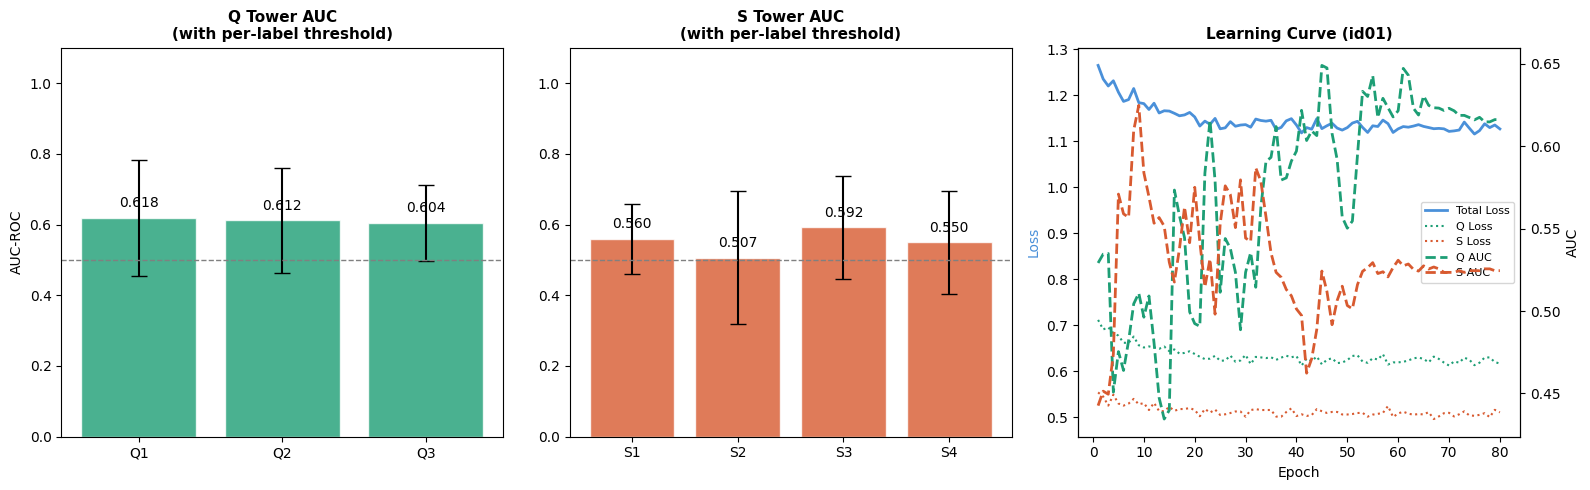

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

# Q AUC
ax = axes[0]
lbls_q = [l for l in Q_COLS if summary_q[l]['auc']]
aucs_q = [np.mean(summary_q[l]['auc']) for l in lbls_q]
stds_q = [np.std(summary_q[l]['auc'])  for l in lbls_q]
bars = ax.bar(lbls_q, aucs_q, yerr=stds_q, capsize=6,
              color='#1D9E75', alpha=0.8, edgecolor='white')
ax.axhline(0.5, color='gray', linestyle='--', lw=1)
ax.set_ylim(0, 1.1)
ax.set_title('Q Tower AUC\n(with per-label threshold)', fontsize=11, fontweight='bold')
ax.set_ylabel('AUC-ROC')
for bar,v in zip(bars, aucs_q):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
            f'{v:.3f}', ha='center', fontsize=10)

# S AUC
ax = axes[1]
lbls_s = [l for l in S_COLS if summary_s[l]['auc']]
aucs_s = [np.mean(summary_s[l]['auc']) for l in lbls_s]
stds_s = [np.std(summary_s[l]['auc'])  for l in lbls_s]
bars = ax.bar(lbls_s, aucs_s, yerr=stds_s, capsize=6,
              color='#D85A30', alpha=0.8, edgecolor='white')
ax.axhline(0.5, color='gray', linestyle='--', lw=1)
ax.set_ylim(0, 1.1)
ax.set_title('S Tower AUC\n(with per-label threshold)', fontsize=11, fontweight='bold')
for bar,v in zip(bars, aucs_s):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
            f'{v:.3f}', ha='center', fontsize=10)

# 학습 곡선
ax = axes[2]
first = list(loso_results.keys())[0]
hist  = loso_results[first]['history']
ep    = range(1, len(hist['loss_total'])+1)
ax2   = ax.twinx()
ax.plot(ep, hist['loss_total'], '#4A90D9', lw=2,   label='Total Loss')
ax.plot(ep, hist['loss_q'],     '#1D9E75', lw=1.5, linestyle=':', label='Q Loss')
ax.plot(ep, hist['loss_s'],     '#D85A30', lw=1.5, linestyle=':', label='S Loss')
ax2.plot(ep, hist['val_q_auc'], '#1D9E75', lw=2,   linestyle='--', label='Q AUC')
ax2.plot(ep, hist['val_s_auc'], '#D85A30', lw=2,   linestyle='--', label='S AUC')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss', color='#4A90D9')
ax2.set_ylabel('AUC')
ax.set_title(f'Learning Curve ({first})', fontsize=11, fontweight='bold')
lines1,_ = ax.get_legend_handles_labels()
lines2,_ = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, [l.get_label() for l in lines1+lines2], fontsize=8)

plt.tight_layout()
plt.savefig('/content/v3_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Feature Attention 시각화

  Dataset: 350샘플 (Q_SEQ=5, S_SEQ=10, augment=False)


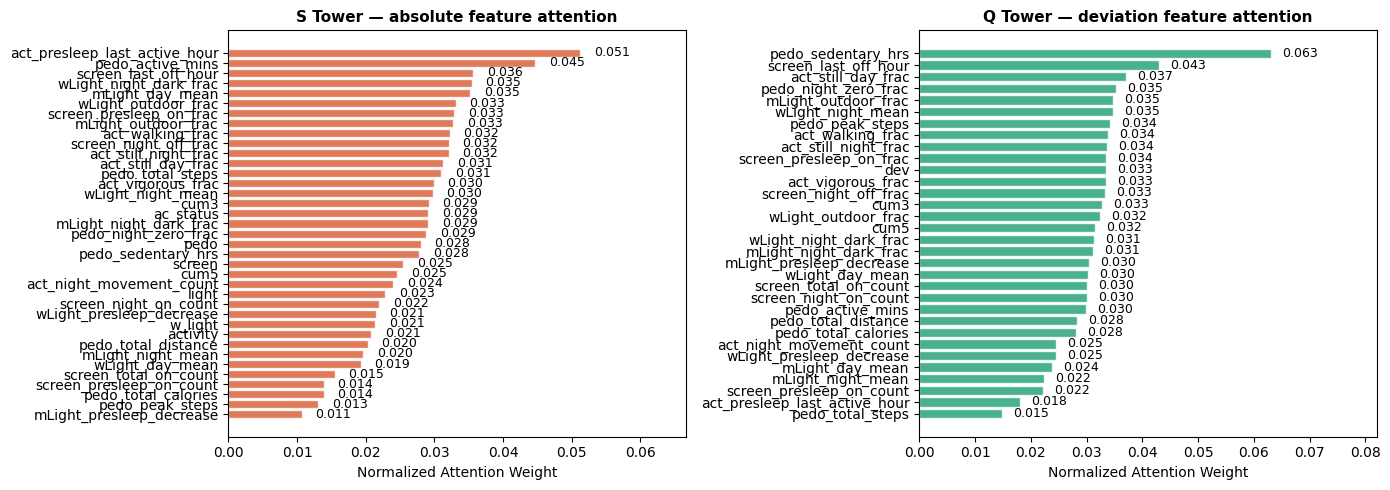

In [ ]:
@torch.no_grad()
def get_attention_weights(model, loader, device):
    model.eval()
    all_ar, all_ad = [], []
    for xr_q, xd_q, xr_s, _, _ in loader:
        xr_q,xd_q = xr_q.to(device),xd_q.to(device)
        _, ar, _ = model.feat_attn_raw(xr_q)
        _, ad, _ = model.feat_attn_dev(xd_q)
        all_ar.append(ar.cpu().numpy()); all_ad.append(ad.cpu().numpy())
    return np.vstack(all_ar).mean(0), np.vstack(all_ad).mean(0)

first_subj = list(loso_results.keys())[0]
vis_model  = loso_results[first_subj]['model']
vis_ds     = DualTowerDataset(
    full_dev_df, raw_feat_cols_ext, dev_feat_cols_ext, Q_COLS, S_COLS, Q_SEQ, S_SEQ)
vis_loader = DataLoader(vis_ds, batch_size=32, shuffle=False)
alpha_raw, alpha_dev = get_attention_weights(vis_model, vis_loader, device)

def group_by_sensor(feat_cols, alpha_vals):
    sensor_map = {}
    for col, val in zip(feat_cols, alpha_vals):
        sensor = col.split('__')[0]
        sensor_map.setdefault(sensor, []).append(val)
    return dict(sorted(sensor_map.items(), key=lambda x: -np.mean(x[1])))

sensor_r = group_by_sensor(raw_feat_cols_ext, alpha_raw)
sensor_d = group_by_sensor(dev_feat_cols_ext, alpha_dev)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
for ax, data, title, color in [
    (axes[0], sensor_r, 'S Tower — absolute feature attention', '#D85A30'),
    (axes[1], sensor_d, 'Q Tower — deviation feature attention', '#1D9E75'),
]:
    sensors = list(data.keys())
    values  = np.array([np.mean(v) for v in data.values()])
    values  = values / values.sum()
    bars = ax.barh(sensors[::-1], values[::-1], color=color, alpha=0.8, edgecolor='white')
    ax.set_xlabel('Normalized Attention Weight')
    ax.set_title(title, fontsize=11, fontweight='bold')
    for bar,v in zip(bars, values[::-1]):
        ax.text(v+0.002, bar.get_y()+bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=9)
    ax.set_xlim(0, values.max()*1.3)
plt.tight_layout()
plt.savefig('/content/v3_attention.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. 피험자 × 레이블 AUC 히트맵

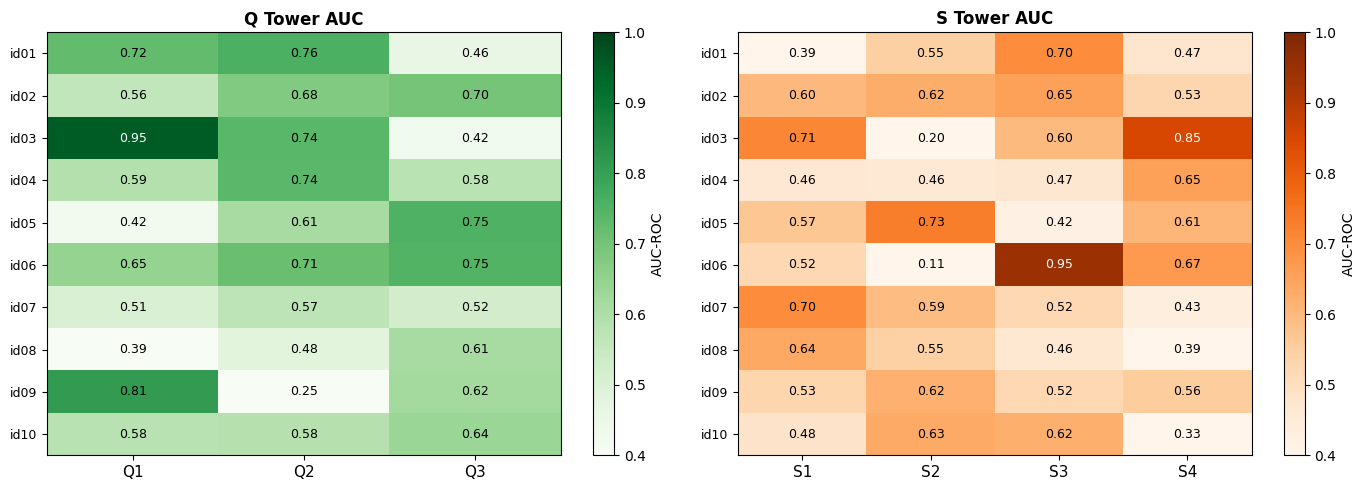

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(14,5))
subj_list = list(loso_results.keys())

for ax, tower, lbl_list, title, cmap in [
    (axes[0],'q_metrics',Q_COLS,'Q Tower AUC','Greens'),
    (axes[1],'s_metrics',S_COLS,'S Tower AUC','Oranges'),
]:
    mat = np.array([
        [loso_results[s][tower].get(l,{}).get('auc',0.5) for l in lbl_list]
        for s in subj_list
    ])
    im = ax.imshow(mat, cmap=cmap, vmin=0.4, vmax=1.0, aspect='auto')
    plt.colorbar(im, ax=ax, label='AUC-ROC')
    ax.set_xticks(range(len(lbl_list))); ax.set_xticklabels(lbl_list, fontsize=11)
    ax.set_yticks(range(len(subj_list))); ax.set_yticklabels(subj_list, fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    for i in range(len(subj_list)):
        for j in range(len(lbl_list)):
            tc = 'white' if mat[i,j]>0.85 else 'black'
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center', fontsize=9, color=tc)
plt.tight_layout()
plt.savefig('/content/v3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Dropout 과적합 진단

> **[수정 D] dropout 조정 가이드**
> 아래 차트에서 train loss와 val AUC의 갭을 확인하세요.
> - train loss 계속 감소 + val AUC 정체 → 과적합 → `dropout=0.3` 시도
> - 두 곡선이 함께 개선됨 → 과적합 없음 → dropout 유지


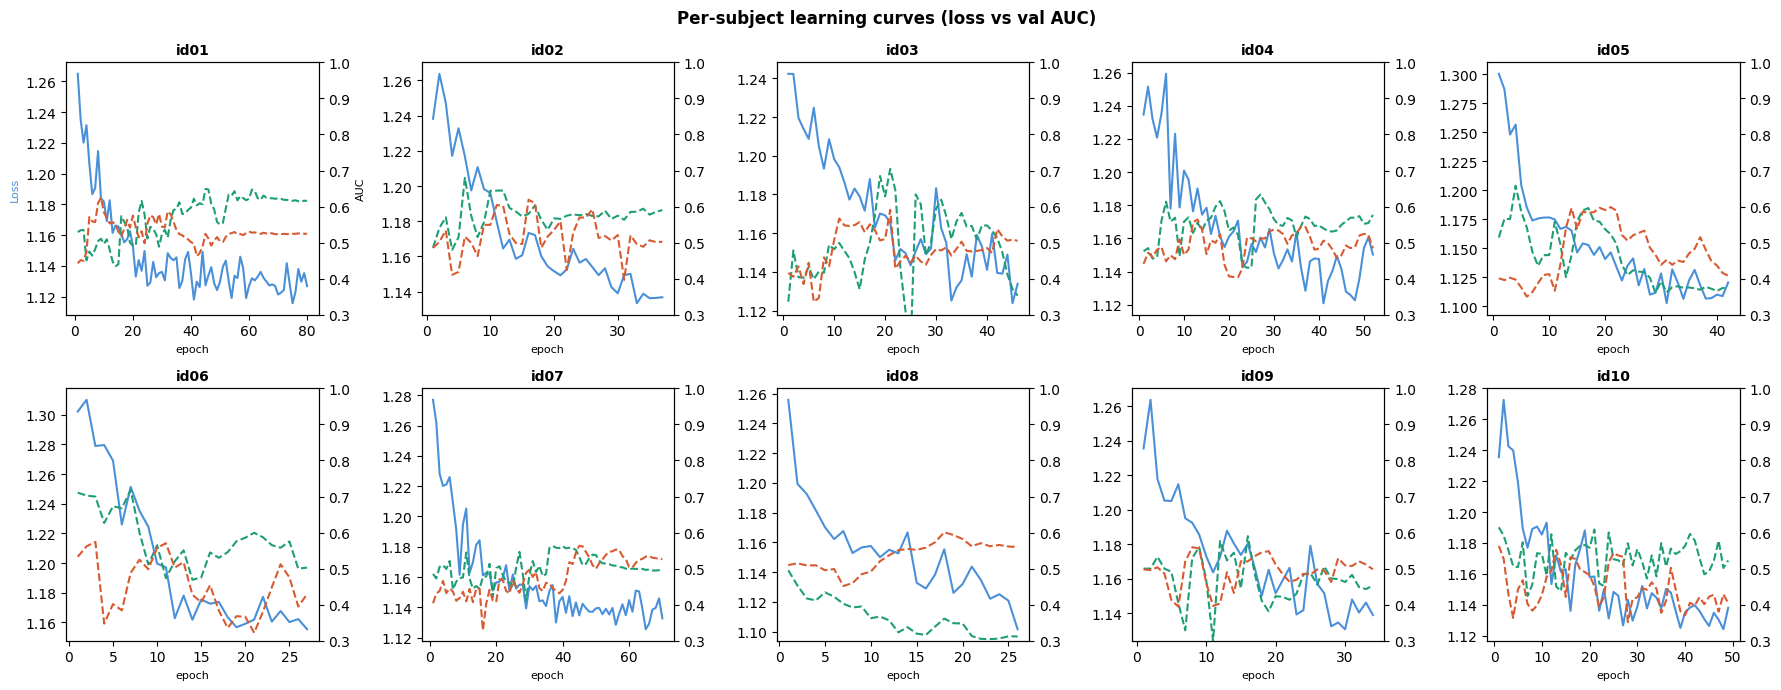

학습 곡선 분석 기준:
  loss 계속 하강 + AUC 정체 → dropout 0.3으로 올리기
  loss·AUC 동반 수렴       → 현재 dropout 유지
  AUC 조기 상승 후 하락    → patience 줄이기 or lr 낮추기


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for idx, subj in enumerate(sorted(loso_results.keys())):
    if idx >= 10: break
    ax  = axes[idx]
    hist= loso_results[subj]['history']
    ep  = range(1, len(hist['loss_total'])+1)
    ax2 = ax.twinx()
    ax.plot(ep, hist['loss_total'], '#4A90D9', lw=1.5, label='loss')
    ax2.plot(ep, hist['val_q_auc'], '#1D9E75', lw=1.5, linestyle='--', label='Q AUC')
    ax2.plot(ep, hist['val_s_auc'], '#D85A30', lw=1.5, linestyle='--', label='S AUC')
    ax.set_title(f'{subj}', fontsize=10, fontweight='bold')
    ax.set_xlabel('epoch', fontsize=8)
    if idx==0:
        ax.set_ylabel('Loss', fontsize=8, color='#4A90D9')
        ax2.set_ylabel('AUC',  fontsize=8)
    ax2.set_ylim(0.3, 1.0)

plt.suptitle('Per-subject learning curves (loss vs val AUC)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/v3_learning_curves.png', dpi=130, bbox_inches='tight')
plt.show()

print('학습 곡선 분석 기준:')
print('  loss 계속 하강 + AUC 정체 → dropout 0.3으로 올리기')
print('  loss·AUC 동반 수렴       → 현재 dropout 유지')
print('  AUC 조기 상승 후 하락    → patience 줄이기 or lr 낮추기')

## 14. 모델 저장 및 추론

In [ ]:
print('🔄 전체 데이터로 최종 모델 재학습...')
full_ds     = DualTowerDataset(
    full_dev_df, raw_feat_cols_ext, dev_feat_cols_ext, Q_COLS, S_COLS, Q_SEQ, S_SEQ)
full_loader = DataLoader(full_ds, batch_size=CONFIG['batch_size'], shuffle=True)

final_model = DualTowerPTDT(
    n_raw=N_RAW, n_dev=N_DEV,
    d_model=CONFIG['d_model'], n_heads=CONFIG['n_heads'],
    n_layers=CONFIG['n_layers'], d_ff=CONFIG['d_ff'],
    dropout=0.05,   # 최종 모델은 dropout 낮춤
    q_seq=Q_SEQ, s_seq=S_SEQ,
    use_cross_tower=CONFIG['use_cross_tower']
).to(device)

optimizer = torch.optim.AdamW(
    final_model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scheduler = get_warmup_scheduler(optimizer, CONFIG['warmup_epochs'], CONFIG['epochs'])

for epoch in range(1, CONFIG['epochs']+1):
    losses = train_one_epoch(final_model, full_loader, optimizer, device)
    scheduler.step()
    if epoch%20==0:
        print(f'  Epoch {epoch:3d} | Loss={losses["total"]:.4f}')

# LOSO threshold 평균을 최종 threshold로 사용
final_thr_q = {
    lbl: np.mean([loso_results[s]['thr_q'].get(lbl,0.5) for s in loso_results])
    for lbl in Q_COLS
}
final_thr_s = {
    lbl: np.mean([loso_results[s]['thr_s'].get(lbl,0.5) for s in loso_results])
    for lbl in S_COLS
}
print(f'\n최종 threshold — Q: {final_thr_q}')
print(f'최종 threshold — S: {final_thr_s}')

torch.save({
    'model_state'      : final_model.state_dict(),
    'config'           : CONFIG,
    'n_raw'            : N_RAW, 'n_dev': N_DEV,
    'q_seq'            : Q_SEQ, 's_seq': S_SEQ,
    'raw_feat_cols_ext': raw_feat_cols_ext,
    'dev_feat_cols_ext': dev_feat_cols_ext,
    'label_cols'       : LABEL_COLS,
    'final_thr_q'      : final_thr_q,
    'final_thr_s'      : final_thr_s,
}, '/content/dual_tower_ptdt_v3.pth')
print('✅ 저장: /content/dual_tower_ptdt_v3.pth')

🔄 전체 데이터로 최종 모델 재학습...
  Dataset: 350샘플 (Q_SEQ=5, S_SEQ=10, augment=False)
  Epoch  20 | Loss=1.0131
  Epoch  40 | Loss=0.9488
  Epoch  60 | Loss=0.8945
  Epoch  80 | Loss=0.8948

최종 threshold — Q: {'Q1': np.float64(0.41), 'Q2': np.float64(0.352), 'Q3': np.float64(0.406)}
최종 threshold — S: {'S1': np.float64(0.296), 'S2': np.float64(0.32), 'S3': np.float64(0.278), 'S4': np.float64(0.29200000000000004)}
✅ 저장: /content/dual_tower_ptdt_v3.pth


In [ ]:
def predict(model, subject_history_df,
            raw_cols, dev_cols, thr_q, thr_s,
            q_seq=Q_SEQ, s_seq=S_SEQ, device=device):
    model.eval()
    df = subject_history_df.sort_values('date')

    get = lambda cols, n: np.nan_to_num(
        df[cols].tail(n).values.astype(np.float32), nan=0.0)

    xr_q = torch.tensor(np.clip(get(raw_cols, q_seq),-10,10)).unsqueeze(0).to(device)
    xd_q = torch.tensor(np.clip(get(dev_cols, q_seq),-10,10)).unsqueeze(0).to(device)
    xr_s = torch.tensor(np.clip(get(raw_cols, s_seq),-10,10)).unsqueeze(0).to(device)

    with torch.no_grad():
        q_l, s_l, _, _, _ = model(xr_q, xd_q, xr_s)
        q_prob = torch.sigmoid(q_l).cpu().numpy()[0]
        s_prob = torch.sigmoid(s_l).cpu().numpy()[0]

    print('📊 예측 결과:')
    print('  [Q Tower — 주관적]')
    for lbl, p in zip(Q_COLS, q_prob):
        thr  = thr_q.get(lbl, 0.5)
        icon = '✅' if p >= thr else '⚠️ '
        bar  = '█'*int(p*20)+'░'*(20-int(p*20))
        print(f'   {icon} {lbl}: [{bar}] {p:.3f}  (thr={thr:.2f})')
    print('  [S Tower — 객관적]')
    for lbl, p in zip(S_COLS, s_prob):
        thr  = thr_s.get(lbl, 0.5)
        icon = '✅' if p >= thr else '⚠️ '
        bar  = '█'*int(p*20)+'░'*(20-int(p*20))
        print(f'   {icon} {lbl}: [{bar}] {p:.3f}  (thr={thr:.2f})')

# 테스트
test_subj = all_subjects[0]
predict(final_model,
        full_dev_df[full_dev_df['subject_id']==test_subj],
        raw_feat_cols_ext, dev_feat_cols_ext,
        final_thr_q, final_thr_s)

📊 예측 결과:
  [Q Tower — 주관적]
   ✅ Q1: [█████████░░░░░░░░░░░] 0.457  (thr=0.43)
   ✅ Q2: [█████████████░░░░░░░] 0.653  (thr=0.29)
   ✅ Q3: [██████████░░░░░░░░░░] 0.550  (thr=0.41)
  [S Tower — 객관적]
   ✅ S1: [█████████░░░░░░░░░░░] 0.500  (thr=0.32)
   ✅ S2: [████████░░░░░░░░░░░░] 0.431  (thr=0.32)
   ✅ S3: [██████████████░░░░░░] 0.707  (thr=0.33)
   ⚠️  S4: [███████░░░░░░░░░░░░░] 0.351  (thr=0.40)


## 15. 추가 튜닝 가이드

| 관찰 | 조치 |
|------|------|
| train loss 계속 하강 + val AUC 정체 | `dropout` 0.25→0.30 |
| val AUC 수렴 후 하락 | `patience` 줄이기 또는 `lr` 낮추기 |
| Q2 AUC 여전히 0.53 미만 | `CUMULATIVE_KEYWORDS`에 `'ambience'` 추가 (소음=피로 신호) |
| S Tower std 크다 | `LAMBDA_S` 를 1.2~1.5로 올려 S 학습 강조 |
| 피험자별 성능 차이 큼 | `ROLLING_WIN` 14→21 (baseline 더 안정적) |
| 전반적 AUC 정체 | `Q_SEQ=3`, `S_SEQ=14` 조합 시도 |
